# Transfer Learning mit PyTorch: Zoobot (ConvNeXt-Nano)

In diesem Notebook nutzen wir nativ **PyTorch** und die Bibliothek **timm**, um das offiziell vortrainierte Zoobot-Modell `ConvNeXt-Nano` auf den Galaxy10 DECals Datensatz feinzutunen.

Der Workflow ist bewusst auf einen **einzigen stratifizierten Train/Val/Test-Split** reduziert. Die frühere K-Fold-Logik ist entfernt, damit der Ablauf einfacher, schneller und besser reproduzierbar wird.

Zusätzlich gibt es jetzt:

- eine per Bool steuerbare **Fine-Tuning-Option** für den Backbone,
- mehrere **Head-Varianten** als direkte Reaktion auf die aktuellen Resultate des bisherigen Heads,
- das Speichern von **Plots**, **Confusion Matrix** und **Test Accuracy** unter `reports/zoobot/`,
- eine Visualisierung eines **Testbildes** mit Ground Truth und Prediction.

In [25]:
import json
import copy
from pathlib import Path
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.utils.tensorboard import SummaryWriter
import timm
from torchinfo import summary
# Import aus deiner bestehenden Daten-Pipeline
from data import load_data, prepare_splits, NUM_CLASSES, LABEL_DICT

# PyTorch Device Setup (GPU wenn möglich, sonst CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Verwendetes Device: {device}")
print(f"CUDA verfügbar: {torch.cuda.is_available()}")
print(f"PyTorch CUDA Build: {torch.version.cuda}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
else:
    print("Hinweis: Wähle den Kernel torch-gpu-env, sonst läuft PyTorch nur auf CPU.")

Verwendetes Device: cuda
CUDA verfügbar: True
PyTorch CUDA Build: 12.1
GPU: NVIDIA GeForce RTX 2070 SUPER


In [26]:
# --- Experiment-Schalter ---
TRAIN_ALL_HEADS = False  # True = alle Head-Varianten nacheinander trainieren
USE_FINETUNING = True  # True = Backbone mitfinetunen | False = nur Head trainieren
UNFREEZE_ALL = False
HEAD_VARIANT = "dense_only"  # Fallback, falls TRAIN_ALL_HEADS=False
HEAD_VARIANTS_TO_RUN = ["baseline", "wide_bn", "deep_regularized", "layernorm_silu", "dense", "dense_only"] if TRAIN_ALL_HEADS else [HEAD_VARIANT]
SAVE_ARTIFACTS = True

# --- Datenpfade ---
DATA_PATH = "./../data/Galaxy10_DECals.h5"
LOGS_DIR = Path("./../logs/zoobot")
REPORTS_DIR = Path("./../reports/zoobot")
LOGS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
SAVED_HEAD_CHECKPOINT = REPORTS_DIR / "zoobot_dense_only_frozen_20260606_133047_746986_model.pth"

# --- Lauf-Identifikation ---
EXPERIMENT_ID = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
EXPERIMENT_TAG = f"{EXPERIMENT_ID}_{'finetune' if USE_FINETUNING else 'frozen'}"

# --- Daten-Split ---
VAL_SIZE = 0.2
TEST_SIZE = 0.2

# --- Hyperparameter ---
BATCH_SIZE = 32
EPOCHS = 100
WARMUP_EPOCHS = 0 #5
LEARNING_RATE = 1e-4
BACKBONE_LR_FACTOR = 0.1
WEIGHT_DECAY = 1e-4
RANDOM_STATE = 42

In [27]:
print("Lade Rohbilder in den RAM...")
images_raw, labels = load_data(DATA_PATH)

print("Erstelle stratifizierten Train/Val/Test-Split...")
split_folds, X_test, y_test = prepare_splits(
    labels,
    use_kfold=False,
    val_size=VAL_SIZE,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_idx, val_idx = split_folds[0]

print(f"Train-Set Größe: {len(train_idx)}")
print(f"Val-Set Größe: {len(val_idx)}")
print(f"Test-Set Größe: {len(X_test)}")

Lade Rohbilder in den RAM...
Dataset geladen: 17,736 Bilder, Shape (17736, 256, 256, 3)
Erstelle stratifizierten Train/Val/Test-Split...

Split-Modus : Einfacher Train/Val-Split
Train + Val : 14,188 Samples
Test        : 3,548 Samples
  Train 11,350 | Val 2,838
Train-Set Größe: 11350
Val-Set Größe: 2838
Test-Set Größe: 3548


In [28]:
class GalaxyDataset(Dataset):
    """
    PyTorch Dataset, das Bilder aus dem NumPy RAM-Array holt,
    die Channel-Reihenfolge anpasst (H,W,C -> C,H,W) und Augmentierungen anwendet.
    """
    def __init__(self, images_array, labels_array, indices, transform=None):
        self.images = images_array
        self.labels = labels_array
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        # Absoluten Index holen
        real_idx = self.indices[idx]
        
        # Bild (uint8) und Label laden
        img_np = self.images[real_idx]
        label = self.labels[real_idx]
        
        # Keras nutzt (H, W, Channels), PyTorch nutzt (Channels, H, W)
        img_np = np.transpose(img_np, (2, 0, 1))
        
        # Konvertiere zu PyTorch Tensor und normiere auf [0, 1]
        img_tensor = torch.tensor(img_np, dtype=torch.float32) / 255.0
        
        # Wende Data Augmentation an (falls vorhanden)
        if self.transform:
            img_tensor = self.transform(img_tensor)
            
        label_tensor = torch.tensor(label, dtype=torch.long)
        return img_tensor, label_tensor

# Data Augmentation (ähnlich zu deinen Keras-Layern)
train_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
])
# Test/Val braucht keine Augmentierung
val_transforms = None

In [29]:
HEAD_VARIANT_DESCRIPTIONS = {
    "baseline": "Referenzkopf nahe am aktuellen Setup: 256 -> BN -> GELU -> Dropout -> Output",
    "wide_bn": "Breiterer Head mit 512er Einstieg und BatchNorm für stabilere Optimierung",
    "deep_regularized": "Tiefe Variante mit Bottleneck-Schichten und stärkerer Regularisierung",
    "layernorm_silu": "Batch-size-robuste Variante mit LayerNorm und SiLU statt BatchNorm",
    "dense": "Dichte Variante ohne Normalisierung, dafür mit mehr Dropout zur Regularisierung",
    "dense_only": "Sehr einfache Variante mit nur zwei Linear-Schichten und GELU, ohne Dropout oder Normalisierung",
}

def print_model_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params

    print(f"\n{'=' * 40}")
    print("Modell-Parameter Übersicht:")
    print(f"{'=' * 40}")
    # Das :, formatiert die Zahlen mit Tausendertrennzeichen für bessere Lesbarkeit
    print(f"Gesamtanzahl Parameter:  {total_params:,}")
    print(f"Trainierbare Parameter:  {trainable_params:,}")
    print(f"Eingefrorene Parameter:  {frozen_params:,}")
    print(f"{'=' * 40}\n")

def build_classification_head(in_features, num_classes, variant="wide_bn"):
    if variant == "baseline":
        return nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    if variant == "wide_bn":
        return nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),
            nn.Linear(256, num_classes),
        )

    if variant == "deep_regularized":
        return nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.35),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )

    if variant == "layernorm_silu":
        return nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Linear(in_features, 256),
            nn.SiLU(),
            nn.Dropout(0.35),
            nn.Linear(256, 128),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes),
        )
    if variant == "dense":
        return nn.Sequential(
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
    if variant == "dense_only":
        return nn.Sequential(
            nn.Linear(in_features, 256),
            nn.GELU(),
            nn.Linear(256, num_classes),
        )

    raise ValueError(f"Unbekannte Head-Variante: {variant}")


class ZoobotConvNeXtNano(nn.Module):
    def __init__(self, num_classes=10, freeze_backbone=True, head_variant="wide_bn"):
        super().__init__()

        print("Lade Zoobot Base-Model von HuggingFace...")
        self.backbone = timm.create_model(
            "hf_hub:mwalmsley/zoobot-encoder-convnext_nano",
            pretrained=True,
            num_classes=0,
        )

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        in_features = self.backbone.num_features
        self.head_variant = head_variant
        self.head = build_classification_head(in_features, num_classes, variant=head_variant)

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features)


def build_optimizer(model, use_finetuning):
    if use_finetuning:

        trainable_backbone_params = [p for p in model.backbone.parameters() if p.requires_grad]

        return optim.AdamW(
            [
                {"params": trainable_backbone_params, "lr": LEARNING_RATE * BACKBONE_LR_FACTOR},
                {"params": model.head.parameters(), "lr": LEARNING_RATE},
            ],
            weight_decay=WEIGHT_DECAY,
        )

    return optim.AdamW(model.head.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)


def build_run_name(head_variant, use_finetuning):
    finetune_suffix = "finetune" if use_finetuning else "frozen"
    return f"zoobot_{head_variant}_{finetune_suffix}_{EXPERIMENT_ID}"


def build_comparison_name():
    return f"head_comparison_{EXPERIMENT_TAG}"

In [30]:
def train_model(
    images_raw,
    labels,
    train_idx,
    val_idx,
    epochs=20,
    warmup_epochs=5,
    batch_size=32,
    patience=5,
    head_variant="wide_bn",
    use_finetuning=False,
    unfreeze_all=True,
    checkpoint_path=None,
):
    """Trainiert genau ein Modell auf dem stratifizierten Train/Val-Split."""
    run_name = build_run_name(head_variant, use_finetuning)
    print(f"\n{'=' * 50}\nStarte Training: {run_name}\n{'=' * 50}")
    print(HEAD_VARIANT_DESCRIPTIONS[head_variant])

    train_dataset = GalaxyDataset(images_raw, labels, train_idx, transform=train_transforms)
    val_dataset = GalaxyDataset(images_raw, labels, val_idx, transform=val_transforms)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    model = ZoobotConvNeXtNano(
        num_classes=NUM_CLASSES,
        freeze_backbone=True,
        head_variant=head_variant,
    ).to(device)

    if checkpoint_path is not None:
        print(f"\n[INFO] Lade vortrainierte Gewichte aus: {checkpoint_path}")
        # map_location stellt sicher, dass es auf das aktuelle Device (CPU/GPU) gemappt wird
        state_dict = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(state_dict)
        print("[INFO] Gewichte erfolgreich geladen!")

    print_model_parameters(model)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = build_optimizer(model, use_finetuning=False)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    best_val_loss = float("inf")
    best_model_weights = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    writer = SummaryWriter(log_dir=str(LOGS_DIR / run_name))

    example_inputs, _ = next(iter(train_loader))
    example_inputs = example_inputs.to(device) # Wichtig: Auf das gleiche Device wie das Modell schieben

    try:
        writer.add_graph(model, example_inputs)
        print("Modellgraph erfolgreich für TensorBoard aufgezeichnet.")
    except Exception as e:
        print(f"Warnung: Graph konnte nicht erstellt werden. Fehler: {e}")

    is_backbone_unfrozen = False

    for epoch in range(epochs):

        if use_finetuning and not is_backbone_unfrozen and epoch >= warmup_epochs:
            print(f"\n{'-'*60}\n>>> WECHSEL ZU PHASE 2: Backbone wird für Fine-Tuning entfroren! <<<\n{'-'*60}")
            
            if unfreeze_all:
                print("  -> Modus: Komplettes Backbone wird trainiert.")
                for param in model.backbone.parameters():
                    param.requires_grad = True
            else:
                print("  -> Modus: Partiell (Nur 'Stage 4' und finale Norm-Schicht werden trainiert).")
                # ConvNeXt in timm hat ein 'stages' Attribut mit 4 Blöcken. Wir greifen den letzten (-1).
                for param in model.backbone.stages[-1].parameters():
                    param.requires_grad = True
                
                # Die finale Normalisierungs-Schicht des Backbones (falls vorhanden) ebenfalls auftauen
                if hasattr(model.backbone, 'norm'):
                    for param in model.backbone.norm.parameters():
                        param.requires_grad = True
            
            # 2. Optimizer neu aufbauen (enthält nun Backbone mit reduzierter LR + Head)
            optimizer = build_optimizer(model, use_finetuning=True)
            
            # 3. Scheduler neu an den neuen Optimizer koppeln
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
            
            # 4. Kontrollausgabe der Parameterstruktur im Terminal
            print_model_parameters(model)
            
            # 5. Early Stopping Counter zurücksetzen (wichtig, da der Loss beim Phasenwechsel kurz schwanken kann)
            epochs_no_improve = 0
            is_backbone_unfrozen = True

        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, targets in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{epochs} [Train]"):
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_train += targets.size(0)
            correct_train += (predicted == targets).sum().item()

        epoch_train_loss = running_loss / total_train
        epoch_train_acc = correct_train / total_train

        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for inputs, targets in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{epochs} [Val]"):
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)

                running_val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total_val += targets.size(0)
                correct_val += (predicted == targets).sum().item()

        epoch_val_loss = running_val_loss / total_val
        epoch_val_acc = correct_val / total_val

        writer.add_scalar("Loss/Train", epoch_train_loss, epoch)
        writer.add_scalar("Loss/Validation", epoch_val_loss, epoch)
        writer.add_scalar("Accuracy/Train", epoch_train_acc, epoch)
        writer.add_scalar("Accuracy/Validation", epoch_val_acc, epoch)
        writer.add_scalar("Learning Rate/Head", optimizer.param_groups[-1]["lr"], epoch)
        if len(optimizer.param_groups) > 1:
            writer.add_scalar("Learning Rate/Backbone", optimizer.param_groups[0]["lr"], epoch)

        scheduler.step(epoch_val_loss)

        history["train_loss"].append(epoch_train_loss)
        history["train_acc"].append(epoch_train_acc)
        history["val_loss"].append(epoch_val_loss)
        history["val_acc"].append(epoch_val_acc)

        print(
            f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}"
        )

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            print(f"  -> Neues bestes Modell gespeichert! (Val Loss: {best_val_loss:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"\nEarly Stopping ausgelöst nach {epoch + 1} Epochen!")
                break

    writer.close()
    model.load_state_dict(best_model_weights)
    if SAVE_ARTIFACTS:
        model_save_path = REPORTS_DIR / f"{run_name}_model.pth"
        torch.save(model.state_dict(), model_save_path)
        print(f"[INFO] Modell-Gewichte erfolgreich exportiert nach: {model_save_path}")
    return model, history, run_name

In [31]:
trained_models = {}
trained_histories = {}
trained_run_names = {}

for head_variant in HEAD_VARIANTS_TO_RUN:
    model, history, run_name = train_model(
        images_raw=images_raw,
        labels=labels,
        train_idx=train_idx,
        val_idx=val_idx,
        epochs=EPOCHS,
        warmup_epochs=WARMUP_EPOCHS,
        batch_size=BATCH_SIZE,
        patience=6,
        head_variant=head_variant,
        use_finetuning=USE_FINETUNING,
        unfreeze_all=UNFREEZE_ALL,
        checkpoint_path=None,  # Hier könntest du Pfade zu vortrainierten Modellen angeben, falls gewünscht
    )

    trained_models[head_variant] = model
    trained_histories[head_variant] = history
    trained_run_names[head_variant] = run_name

print("\nAbgeschlossene Head-Varianten:")
for head_variant in HEAD_VARIANTS_TO_RUN:
    print(f"- {head_variant}: {trained_run_names[head_variant]}")


Starte Training: zoobot_dense_only_finetune_20260606_142145_646537
Sehr einfache Variante mit nur zwei Linear-Schichten und GELU, ohne Dropout oder Normalisierung
Lade Zoobot Base-Model von HuggingFace...

Modell-Parameter Übersicht:
Gesamtanzahl Parameter:  15,119,226
Trainierbare Parameter:  166,666
Eingefrorene Parameter:  14,952,560

Modellgraph erfolgreich für TensorBoard aufgezeichnet.

------------------------------------------------------------
>>> WECHSEL ZU PHASE 2: Backbone wird für Fine-Tuning entfroren! <<<
------------------------------------------------------------
  -> Modus: Partiell (Nur 'Stage 4' und finale Norm-Schicht werden trainiert).

Modell-Parameter Übersicht:
Gesamtanzahl Parameter:  15,119,226
Trainierbare Parameter:  7,614,986
Eingefrorene Parameter:  7,504,240



Epoch 1/100 [Val]: 100%|██████████| 89/89 [00:05<00:00, 15.24it/s]


Train Loss: 0.6395 | Train Acc: 0.8163 | Val Loss: 0.3879 | Val Acc: 0.8721
  -> Neues bestes Modell gespeichert! (Val Loss: 0.3879)


Epoch 2/100 [Val]: 100%|██████████| 89/89 [00:05<00:00, 15.20it/s]


Train Loss: 0.3633 | Train Acc: 0.8795 | Val Loss: 0.3724 | Val Acc: 0.8798
  -> Neues bestes Modell gespeichert! (Val Loss: 0.3724)


...

Train Loss: 0.2556 | Train Acc: 0.9092 | Val Loss: 0.3555 | Val Acc: 0.8858


Epoch 9/100 [Val]: 100%|██████████| 89/89 [00:05<00:00, 15.10it/s]


Train Loss: 0.2446 | Train Acc: 0.9141 | Val Loss: 0.3618 | Val Acc: 0.8844


Epoch 10/100 [Val]: 100%|██████████| 89/89 [00:05<00:00, 15.00it/s]


Train Loss: 0.2359 | Train Acc: 0.9159 | Val Loss: 0.3637 | Val Acc: 0.8823

Early Stopping ausgelöst nach 10 Epochen!
[INFO] Modell-Gewichte erfolgreich exportiert nach: ..\reports\zoobot\zoobot_dense_only_finetune_20260606_142145_646537_model.pth

Abgeschlossene Head-Varianten:
- dense_only: zoobot_dense_only_finetune_20260606_142145_646537



**************************************************
TEST-EVALUIERUNG
**************************************************
dense_only: Test Accuracy: 0.8808 (88.08%)


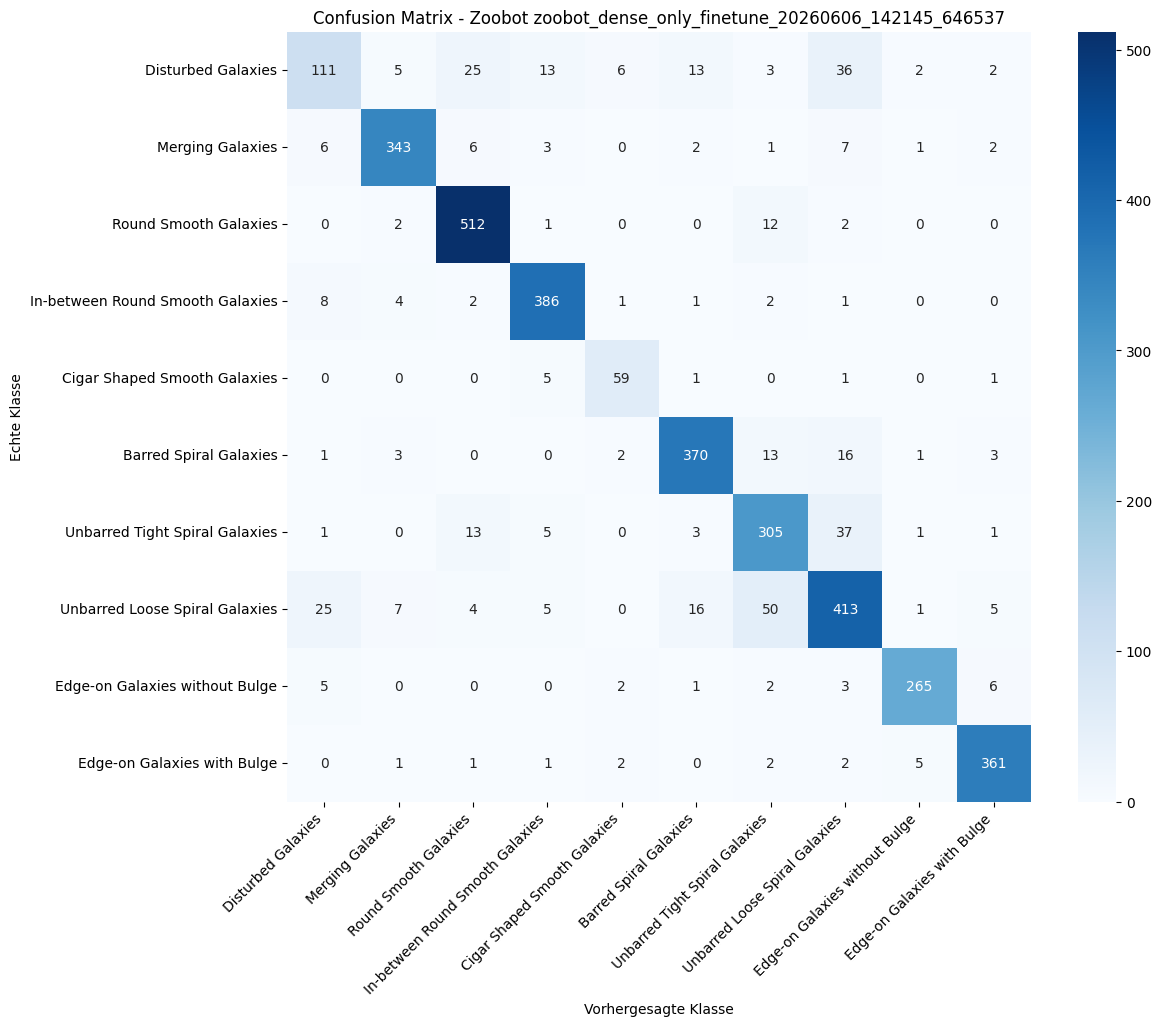

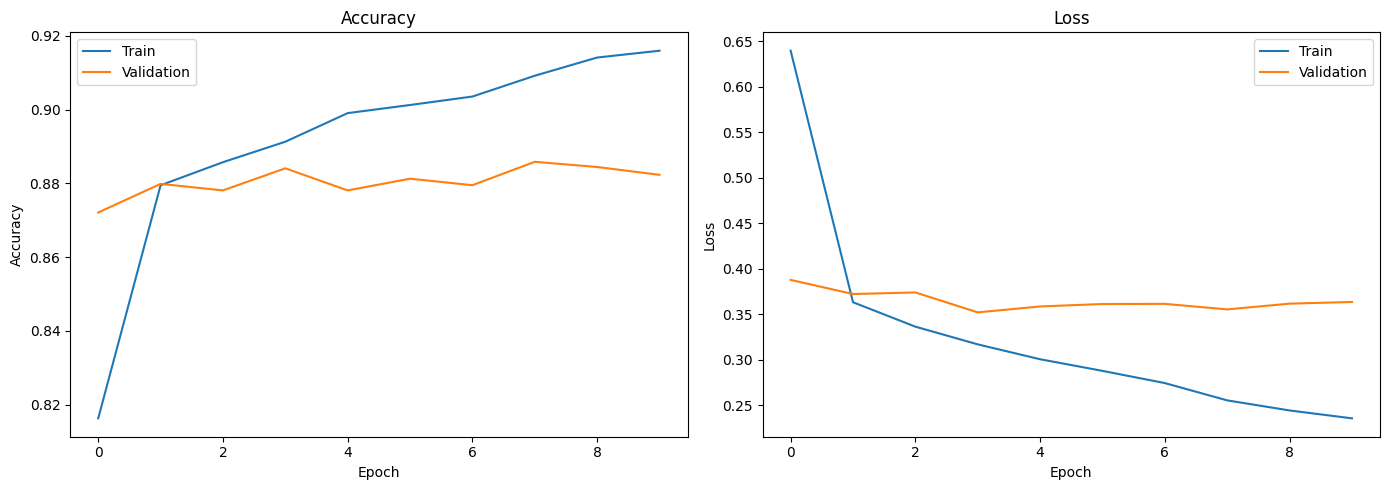

Confusion Matrix gespeichert unter: ..\reports\zoobot\zoobot_dense_only_finetune_20260606_142145_646537_confusion_matrix.png
Trainingskurven gespeichert unter: ..\reports\zoobot\zoobot_dense_only_finetune_20260606_142145_646537_training_curves.png


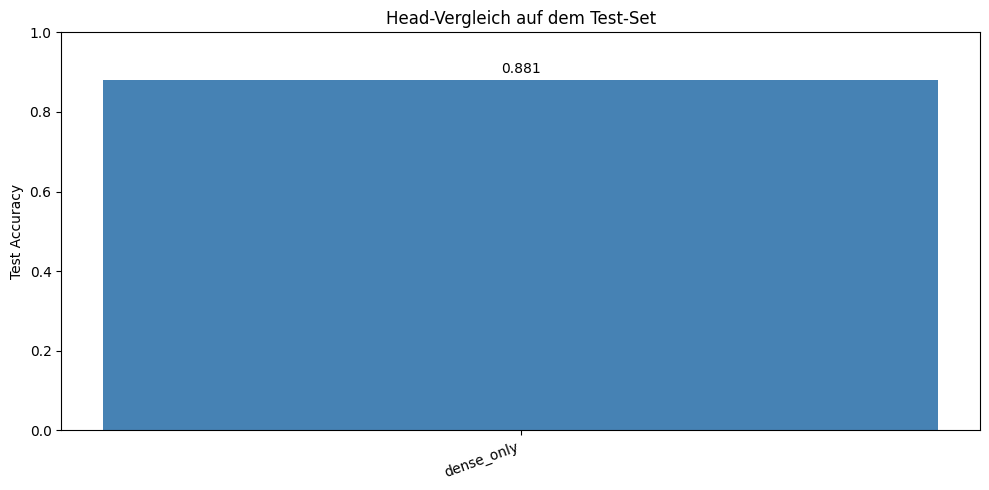

Vergleichs-JSON gespeichert unter: ..\reports\zoobot\head_comparison_20260606_142145_646537_finetune.json
Vergleichsplot gespeichert unter: ..\reports\zoobot\head_comparison_20260606_142145_646537_finetune.png

Bestes Modell: zoobot_dense_only_finetune_20260606_142145_646537 mit 88.08% Accuracy


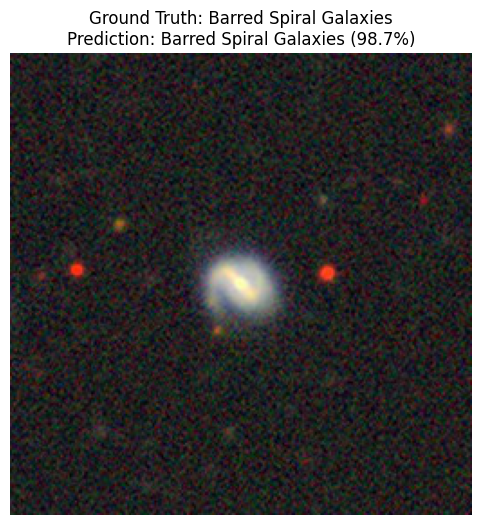

In [32]:
def evaluate_pytorch_model(model, test_idx, images_raw, labels, batch_size=32):
    model.eval()
    test_dataset = GalaxyDataset(images_raw, labels, test_idx, transform=None)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(targets.numpy())

    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    accuracy = float((all_preds == all_targets).mean())

    return accuracy, all_preds, all_targets


def predict_single_image(model, image_np):
    model.eval()
    image_tensor = torch.tensor(np.transpose(image_np, (2, 0, 1)), dtype=torch.float32) / 255.0
    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(image_tensor)
        probabilities = torch.softmax(logits, dim=1)
        confidence, prediction = torch.max(probabilities, dim=1)

    return int(prediction.item()), float(confidence.item())


def save_training_curves(history, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history["train_acc"], label="Train")
    axes[0].plot(history["val_acc"], label="Validation")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(history["train_loss"], label="Train")
    axes[1].plot(history["val_loss"], label="Validation")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def save_confusion_matrix(best_targets, best_preds, save_path, run_name):
    cm = confusion_matrix(best_targets, best_preds)
    class_names = [LABEL_DICT[i] for i in range(NUM_CLASSES)]

    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f"Confusion Matrix - Zoobot {run_name}")
    ax.set_ylabel("Echte Klasse")
    ax.set_xlabel("Vorhergesagte Klasse")
    plt.xticks(rotation=45, ha="right")
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def show_test_example(model, test_idx, images_raw, labels):
    rng = np.random.default_rng(RANDOM_STATE)
    sample_idx = int(rng.choice(np.asarray(test_idx)))
    image_np = images_raw[sample_idx]
    true_label_idx = int(labels[sample_idx])
    predicted_idx, confidence = predict_single_image(model, image_np)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image_np)
    ax.axis("off")
    ax.set_title(
        f"Ground Truth: {LABEL_DICT[true_label_idx]}\n"
        f"Prediction: {LABEL_DICT[predicted_idx]} ({confidence * 100:.1f}%)"
    )

    plt.show()
    plt.close(fig)


print(f"\n{'*' * 50}\nTEST-EVALUIERUNG\n{'*' * 50}")
all_results = []
best_result = None

for head_variant in HEAD_VARIANTS_TO_RUN:
    model = trained_models[head_variant]
    history = trained_histories[head_variant]
    run_name = trained_run_names[head_variant]

    test_accuracy, test_preds, test_targets = evaluate_pytorch_model(model, X_test, images_raw, labels, batch_size=BATCH_SIZE)
    print(f"{head_variant}: Test Accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")

    metrics = {
        "run_name": run_name,
        "head_variant": head_variant,
        "use_finetuning": USE_FINETUNING,
        "test_accuracy": test_accuracy,
        "num_test_samples": int(len(X_test)),
        "num_train_samples": int(len(train_idx)),
        "num_val_samples": int(len(val_idx)),
    }

    if SAVE_ARTIFACTS:
        cm_path = REPORTS_DIR / f"{run_name}_confusion_matrix.png"
        curves_path = REPORTS_DIR / f"{run_name}_training_curves.png"

        save_confusion_matrix(test_targets, test_preds, cm_path, run_name)
        save_training_curves(history, curves_path)

        print(f"Confusion Matrix gespeichert unter: {cm_path}")
        print(f"Trainingskurven gespeichert unter: {curves_path}")

    all_results.append(metrics)
    if best_result is None or test_accuracy > best_result["test_accuracy"]:
        best_result = {
            **metrics,
            "test_preds": test_preds,
            "test_targets": test_targets,
        }

if SAVE_ARTIFACTS:
    comparison_name = build_comparison_name()
    summary_json_path = REPORTS_DIR / f"{comparison_name}.json"
    comparison_plot_path = REPORTS_DIR / f"{comparison_name}.png"

    sorted_results = sorted(all_results, key=lambda item: item["test_accuracy"], reverse=True)

    with summary_json_path.open("w", encoding="utf-8") as f:
        json.dump(sorted_results, f, indent=2)

    fig, ax = plt.subplots(figsize=(10, 5))
    labels_for_plot = [item["head_variant"] for item in sorted_results]
    accuracies_for_plot = [item["test_accuracy"] for item in sorted_results]
    bars = ax.bar(labels_for_plot, accuracies_for_plot, color="steelblue")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Test Accuracy")
    ax.set_title("Head-Vergleich auf dem Test-Set")
    ax.bar_label(bars, fmt="%.3f", padding=3)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    fig.savefig(comparison_plot_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    print(f"Vergleichs-JSON gespeichert unter: {summary_json_path}")
    print(f"Vergleichsplot gespeichert unter: {comparison_plot_path}")

best_variant = best_result["head_variant"]
best_model = trained_models[best_variant]
best_run_name = best_result["run_name"]
print(f"\nBestes Modell: {best_run_name} mit {best_result['test_accuracy'] * 100:.2f}% Accuracy")
show_test_example(best_model, X_test, images_raw, labels)